In [1]:
import torch

X = torch.tensor([[1.0, 4.0, 7.0], [2.0, 3.0, 6.0]])

X

tensor([[1., 4., 7.],
        [2., 3., 6.]])

In [ ]:
# shape

X.shape

torch.Size([2, 3])

In [ ]:
# data type
X.dtype

torch.float32

In [4]:
# indexing
X[0, 1]

tensor(4.)

In [5]:
X[:, 1]

tensor([4., 3.])

In [6]:
# math

10 * (X + 1.0)

tensor([[20., 50., 80.],
        [30., 40., 70.]])

In [ ]:
X.exp()

tensor([[   2.7183,   54.5982, 1096.6332],
        [   7.3891,   20.0855,  403.4288]])

In [8]:
X.mean()

tensor(3.8333)

In [9]:
X.max(dim=0)  # max values along dimension 0 (i.e., max value per column)

torch.return_types.max(
values=tensor([2., 4., 7.]),
indices=tensor([1, 0, 0]))

In [10]:
X @ X.T  # matrix transpose and matrix multiplication

tensor([[66., 56.],
        [56., 49.]])

In [11]:
import numpy as np
X.numpy()

array([[1., 4., 7.],
       [2., 3., 6.]], dtype=float32)

In [ ]:
torch.tensor(np.array([[1., 4., 7.], [2., 3., 6.]]))

# note that you should always stick to dtype=float32

tensor([[1., 4., 7.],
        [2., 3., 6.]], dtype=torch.float64)

In [15]:
torch.FloatTensor(np.array([[1., 4., 7.], [2., 3., 6]]))

tensor([[1., 4., 7.],
        [2., 3., 6.]])

In [17]:
X[:, 1] = -99
X

tensor([[  1., -99.,   7.],
        [  2., -99.,   6.]])

In [18]:
X.relu_()
X

tensor([[1., 0., 7.],
        [2., 0., 6.]])

In [ ]:
# Hardware acceleration

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'mps'

In [21]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]])
M = M.to(device)

In [22]:
M.device

device(type='mps', index=0)

In [23]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]], device=device)

In [24]:
R = M @ M.T  # run some operations on the GPU
R

tensor([[14., 32.],
        [32., 77.]], device='mps:0')

In [25]:
M = torch.rand((1000, 1000))  # on the CPU
%timeit M @ M.T

585 μs ± 532 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [26]:
M = torch.rand((1000, 1000), device=device)
%timeit M @ M.T

377 μs ± 1.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [28]:
x = torch.tensor(5.0, requires_grad=True)
f = x ** 2
f

tensor(25., grad_fn=<PowBackward0>)

In [ ]:
f.backward()
x.grad

tensor(10.)

In [80]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [77]:
import numpy as np
import torch
from sklearn.datasets import load_sample_images

sample_images = np.stack(load_sample_images()["images"])
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255

In [78]:
sample_images.shape

torch.Size([2, 427, 640, 3])

In [79]:
# PyTorch expects the channel dimension to be just before the height and width dimensions, not after,
# so we need to permute the dimensions using the permute() method:

sample_images_permuted = sample_images.permute(0, 3, 1, 2)
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

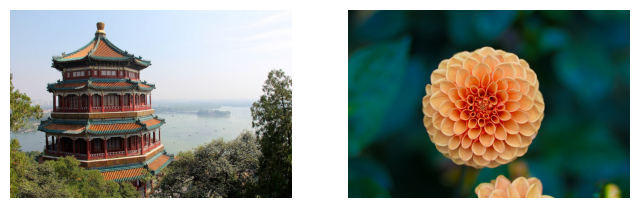

In [81]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plt.figure(figsize=(8, 4))
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)

In [32]:
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
from functools import partial

In [ ]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [36]:
# To find the list of pretrained weights available for a given model, such as convnext_base, run
list(torchvision.models.get_model_weights("convnext_base"))

[ConvNeXt_Base_Weights.IMAGENET1K_V1]

In [ ]:
# Load a ConvNeXt model pretrained on ImageNet with the following code.
# There are several variants of the ConvNeXt model—tiny, small, base, and large—and this code loads the base variant

weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /Users/lucasnseyep/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100.0%


In [ ]:
# That’s all! This code automatically downloads the weights (338 MB) from the Torch Hub, an online repository of
# pretrained models. The weights are saved and cached for future use in the below:

torch.hub.get_dir()

'/Users/lucasnseyep/.cache/torch/hub'

In [40]:
transforms = weights.transforms()
preprocessed_images = transforms(sample_images_permuted)

In [41]:
model.eval()
with torch.no_grad():
    y_logits = model(preprocessed_images.to(device))

In [42]:
y_pred = torch.argmax(y_logits, dim=1)
y_pred

tensor([698, 985], device='mps:0')

In [43]:
class_names = weights.meta["categories"]
[class_names[class_id] for class_id in y_pred]

['palace', 'daisy']

In [64]:
y_top3_logits, y_top3_class_ids = y_logits.topk(k=3, dim=1)
[[class_names[class_id] for class_id in top3] for top3 in y_top3_class_ids]

[['palace', 'monastery', 'lakeside'], ['daisy', 'pot', 'ant']]

In [65]:
y_top3_logits.softmax(dim=1)

tensor([[0.8618, 0.1185, 0.0197],
        [0.8106, 0.0964, 0.0930]], device='mps:0')

# Pretrained Models for Transfer Learning


In [92]:
DefaultFlowers102 = partial(torchvision.datasets.Flowers102, root="datasets",
                            transform=weights.transforms(), download=True)

train_set = DefaultFlowers102(split="train")
valid_set = DefaultFlowers102(split="val")
test_set = DefaultFlowers102(split="test")

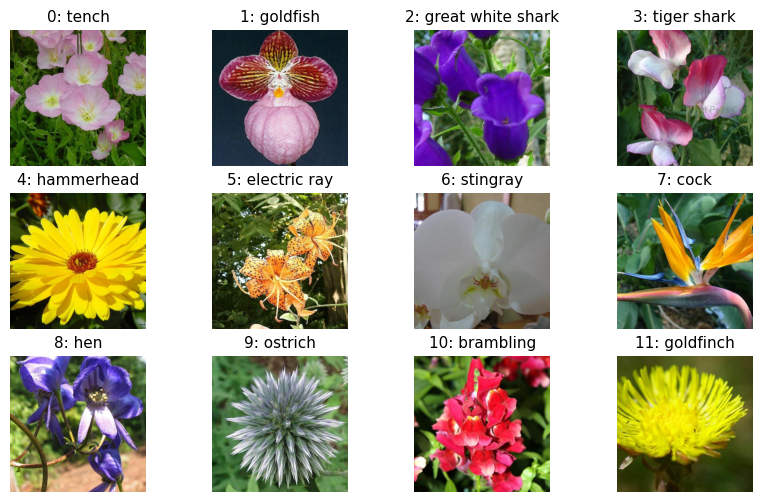

In [93]:
# extra code – displays the 1st image of classes 0 to 11 in the train set

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop(500),
])
flowers_to_display = DefaultFlowers102(split="train", transform=transform)
sample_flowers = sorted({y: img for img, y in flowers_to_display}.items())[:12]

plt.figure(figsize=(10, 6))
for class_id, image in sample_flowers:
    if class_id == 12: break
    plt.subplot(3, 4, class_id + 1)
    plot_image(image)
    plt.title(f"{class_id}: {class_names[class_id]}", fontsize=11)

plt.show()

In [94]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

In [95]:
# Now let’s adapt our pretrained ConvNeXt-base model to this dataset. Since it was pretrained on ImageNet,
# which has 1,000 classes, the model’s head (i.e., its upper layers) was designed to output 1,000 logits.
# But we only have 102 classes, so we must chop the model’s head off and replace it with a smaller one.
# But how can we find it? Well let’s use the model’s named_children() method to find the name of its submodules:
[name for name, child in model.named_children()]

['features', 'avgpool', 'classifier']

In [96]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=102, bias=True)
)

In [97]:
n_classes = 102
model.classifier[2] = nn.Linear(1024, n_classes).to(device)

In [98]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [99]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [100]:
n_epochs = 5
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=102).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 3.3120, train metric: 0.4961, valid metric: 0.8559
Epoch 2/5, train loss: 0.8103, train metric: 0.9892, valid metric: 0.9167
Epoch 3/5, train loss: 0.2371, train metric: 0.9980, valid metric: 0.9186
Epoch 4/5, train loss: 0.1206, train metric: 1.0000, valid metric: 0.9245
Epoch 5/5, train loss: 0.0836, train metric: 1.0000, valid metric: 0.9294


In [101]:
evaluate_tm(model, test_loader, accuracy)

tensor(0.9070, device='mps:0')

In [105]:
from PIL import Image
import os

def convert_png_to_jpg(png_image_path, jpg_output_path):
    # Open the image
    try:
        image = Image.open(png_image_path)
    except FileNotFoundError:
        print(f"Error: The file '{png_image_path}' was not found.")
        return

    # Convert the image to RGB mode
    # JPG format does not support transparency (alpha channel), so it must be removed.
    if image.mode in ('RGBA', 'P'):
        # Create a new white background image
        bg = Image.new('RGB', image.size, (255, 255, 255))
        # Paste the transparent image onto the white background
        bg.paste(image, (0, 0), image)
        image = bg

    # Save the image with the .jpg extension
    image.save(jpg_output_path, format='JPEG')
    print(f"Image successfully converted and saved as '{jpg_output_path}'")

# Example Usage:
input_file = 'datasets/flowers-102/image.png'
output_file = 'datasets/flowers-102/image.jpg'
convert_png_to_jpg(input_file, output_file)

Image successfully converted and saved as 'datasets/flowers-102/image.jpg'


In [114]:
test_image = Image.open(output_file)

In [115]:
test_image = np.stack(np.asarray(test_image))
test_image = torch.tensor(test_image, dtype=torch.float32) / 255


In [119]:
test_image_permuted = test_image.permute(2, 0, 1)
test_image_permuted.shape

torch.Size([3, 1125, 2000])

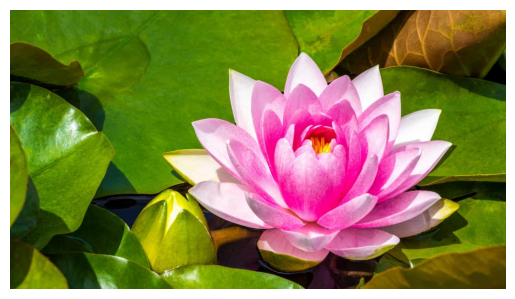

In [120]:
plot_image(test_image_permuted)

In [123]:
transforms = weights.transforms()
preprocessed_image = transforms(test_image_permuted)
preprocessed_image = preprocessed_image.unsqueeze(0)

In [124]:
model.eval()
with torch.no_grad():
    y_logits = model(preprocessed_image.to(device))

In [125]:
y_pred = torch.argmax(y_logits, dim=1)
y_pred

tensor([72], device='mps:0')

In [129]:
class_names = train_set.classes
[class_names[class_id] for class_id in y_pred]

['water lily']